# **EXPERIMENTO 02 - Regressão Linear Univariada - Método Gradiente Descendente**

In [90]:
# Importação do conjunto de dados "Boston House Price Dataset.csv".

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

data = np.loadtxt("boston_housing.csv", delimiter=",", skiprows=1)

V = data[:,[1,3]]

In [91]:
# Implantação da função "standardize(V)" que recebe um vetor V e retorna o vetor V padronizado.

# Padronização da variável LSTAT como atributo preditor e da variável MEDV como atributo alvo. Obtendo o vetor as observações da coluna LSTAT e o vetor com as observações da coluna MEDV.

def standardize (V):

    data_padronizado = np.zeros(V.shape)

    media0 = np.mean(V[:,0])
    desv0 = np.std(V[:,0])
    data_padronizado[:,0] = (V[:,0] - media0) / desv0

    media1 = np.mean(V[:,1])
    desv1 = np.std(V[:,1])
    data_padronizado[:,1] = (V[:,1] - media1) / desv1

    return (data_padronizado)

In [92]:
# Valores padronizados.

data_padronizado = standardize(V)

X_true = data_padronizado[:,0]
y_true = data_padronizado[:,1]

df_pandas = pd.DataFrame (data_padronizado, columns = ['X','Y'])

X_p = df_pandas['X']
y_p = df_pandas['Y']

In [93]:
# Treinamento do método de regressão linear univariada usando o método "Gradiente Descendente".

def regressao_linear(X, y, alpha, n_epocas):

    b0 = 0
    b1 = 0

    lista_mse = []
    lista_r2 = []

    for i in range (n_epocas):

        y_predict = b0 + b1*X
        e = y - y_predict
        b0 = b0 + alpha*np.mean(e)
        b1 = b1 + alpha*np.mean(e*X)

        mse = np.mean ((y - y_predict)**2)
        r2 = 1 - np.sum((y - y_predict)**2) / np.sum((y-(np.mean(y)))**2)

        lista_mse.append(mse)
        lista_r2.append(r2)

    array_mse = np.array(lista_mse)
    array_r2 = np.array(lista_r2)

    return (b0, b1, array_mse, array_r2)

In [94]:
# Coeficientes finais

b0, b1, array_mse, array_r2 = regressao_linear(X_true, y_true, 0.01, 1000)
print ("b0:", np.round(b0, 4), f"\n", "b1:", np.round(b1, 4))

b0: -0.0 
 b1: -0.7606


In [95]:
# Resumo da análise da regressão, utilizando a biblioteca statsmodels (com o método Ordinary Least Squares).

modelo = smf.ols ('Y ~ X', data = df_pandas)
modelo = modelo.fit()
modelo.summary()

print (modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.579
Model:                            OLS   Adj. R-squared:                  0.578
Method:                 Least Squares   F-statistic:                     668.7
Date:                Fri, 24 Oct 2025   Prob (F-statistic):           1.93e-93
Time:                        12:41:11   Log-Likelihood:                -482.56
No. Observations:                 489   AIC:                             969.1
Df Residuals:                     487   BIC:                             977.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.361e-17      0.029   4.63e-16      1.0

In [96]:
# Predições, Predições convertidas de volta à unidade original (Revertidas à escala original), MSE e R² obtidos com o modelo final.

def predict_univariate(X_true, b0, b1):
    y_predict = b0 + (b1*X_true)

    return y_predict

def predict_univariate_esc_original(y_predict):

    y_predict_orig = y_predict * np.std(V[:,1]) + np.mean(V[:,1])

    return y_predict_orig

def MSE (y_true, y_predict):
    mse = np.mean ((y_true - y_predict)**2)

    return mse

def R2 (y_true, y_predict):
    r2 = 1 - np.sum((y_true-y_predict)**2) / np.sum((y_true-(np.mean(y_true)))**2)

    return r2

In [97]:
# Predições:
y_predict = predict_univariate(X_true, b0, b1)
print ("Predições:",f"\n", np.round(y_predict, 2),f"\n")

# Predições - Valores. -- Predições convertidas de volta à unidade original (Revertidas à escala original):
y_predict_orig = predict_univariate_esc_original (y_predict)
print ("Predições com valores convertidos à unidade original:", f"\n", np.round(y_predict_orig, 2),f"\n")

# MSE calculado/atualizado a cada rodada:
print ("MSE atualizado a cada rodada:",f"\n", np.round(array_mse, 2),f"\n")

# R² calculado/atualizado a cada rodada:
print ("R² atualizado a cada rodada:",f"\n", np.round(array_r2, 2))

Predições: 
 [ 0.86  0.41  0.96  1.08  0.82  0.83  0.05 -0.67 -1.83 -0.45 -0.81 -0.04
 -0.3   0.5   0.29  0.48  0.68 -0.19  0.13  0.18 -0.87 -0.1  -0.62 -0.75
 -0.36 -0.38 -0.2  -0.47  0.02  0.1  -1.04 -0.01 -1.59 -0.58 -0.8   0.35
  0.16  0.45  0.3   0.93  1.18  0.87  0.77  0.59  0.36  0.29 -0.13 -0.63
 -1.92 -0.35 -0.05  0.38  0.82  0.48 -0.2   0.87  0.77  0.97  0.65  0.4
 -0.02 -0.16  0.67  0.37  0.53  0.89  0.29  0.52 -0.02  0.45  0.67  0.33
  0.8   0.58  0.66  0.43  0.1   0.29  0.06  0.41  0.82  0.61  0.67  0.58
  0.36  0.69  0.01  0.48  0.8   0.78  0.44  0.51  0.51  0.72  0.25  0.68
  0.17  0.94  1.01  0.73  0.38  0.57  0.25 -0.05  0.07 -0.38 -0.62 -0.12
  0.07 -0.28 -0.01  0.3  -0.35 -0.45  0.27 -0.3   0.1   0.28 -0.26 -0.07
 -0.15 -0.14 -0.54 -1.34 -0.5  -0.2  -1.54 -0.46 -0.26 -0.58  0.04  0.07
  0.2  -0.22 -0.47 -0.43 -0.43 -0.18 -0.9  -0.59 -1.21 -2.31 -1.49 -1.45
 -1.76 -1.6  -0.4  -1.78 -1.65 -0.91 -0.12 -0.04  0.09 -0.31 -0.23 -0.22
 -0.34  0.9   0.7   0.6   0.8   0.14  0

In [98]:
# MSE

mse = MSE (y_true, y_predict)
print ("MSE:", np.round(mse, 2))

MSE: 0.42


In [99]:
# R²

r2 = R2 (y_true, y_predict)
print ("R²:", np.round(r2, 2))

R²: 0.58


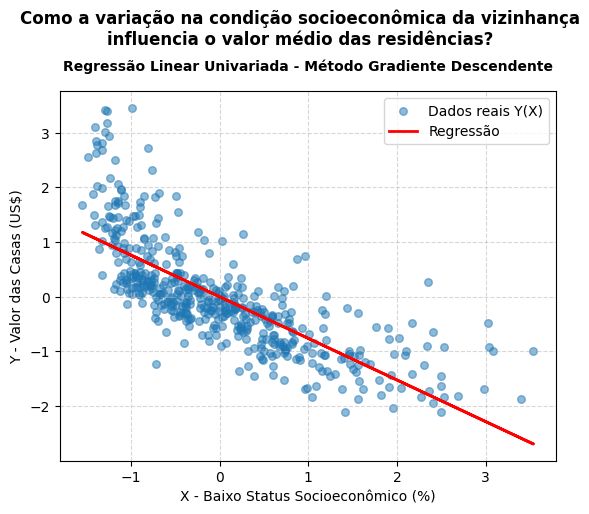

In [132]:
# Visualização gráfica da regressão linear univariada pelo método analítico.

plt.scatter(X_true, y_true, label = "Dados reais Y(X)", s=30, alpha=0.5)
plt.plot(X_true, y_predict, color='red', label = "Regressão", linewidth=2)
plt.suptitle("Como a variação na condição socioeconômica da vizinhança\ninfluencia o valor médio das residências?", fontsize=12, fontweight='bold', y=1.05)
plt.title("Regressão Linear Univariada - Método Gradiente Descendente", fontsize=10, fontweight='bold', pad =15)
plt.xlabel("X - Baixo Status Socioeconômico (%)", fontsize=10)
plt.ylabel("Y - Valor das Casas (US$)", fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()